In [11]:
from pathlib import Path
path_to_data_notebook = Path.cwd().parent.parent / "Data" / "1_Preprocesed_data.ipynb"
%run {path_to_data_notebook}

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
import datetime 
import time
from sklearn.model_selection import train_test_split

In [24]:
size = 40
x_range_to_cut = False
df = get_whole_preprocessed_dataframe(size, x_range_to_cut)
# choosen property for y:
choosen_property_1 = "Total_surface_area[m2/g]"
choosen_property_2 = "Total_pore_volume[cm3/g]"
choosen_property_3 = "Micropore_volume[cm3/g]"

df_with_data = df[(df[choosen_property_1].notna()) & (df[choosen_property_2].notna()) & (df[choosen_property_3].notna())] # get data if all 3 choosen property are present
df_without_data = df[(df[choosen_property_1].isna()) | (df[choosen_property_2].isna()) | (df[choosen_property_3].isna())] # get data if only one choosen property are missing

X = df_with_data['processed_flatten_isotherm_X_Y'] # x = 'processed_flatten_isotherm_X_Y'
y = df_with_data # y - temporary all columns for prediction inspection, in next steps we extract only choosen property

X_train, X_test, y_train_nested, y_test_nested, = train_test_split(X, y, test_size=0.02, random_state=42) #random_state=42

# X_train = X_train.tolist()
# X_test = X_test.tolist()
# y_train = y_train_nested[[choosen_property_1,choosen_property_2,choosen_property_3]].to_numpy()
# y_test = y_test_nested[[choosen_property_1,choosen_property_2,choosen_property_3]].to_numpy() 

y_train = np.array(X_train.tolist())
y_test = np.array(X_test.tolist())
X_train = y_train_nested[[choosen_property_1,choosen_property_2,choosen_property_3]].to_numpy()
X_test = y_test_nested[[choosen_property_1,choosen_property_2,choosen_property_3]].to_numpy() 


scaler = StandardScaler() # only for x data
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 

print(f'X_train size = {len(X_train)}')
print(f'y_train size = {len(y_train)}')
print(f'X_test size = {len(X_test)}')
print(f'y_test size = {len(y_test)}')

/home/pc/moje/python_projects/adsorbents_isotherms/Data/all_data.csv
------------------------------- Preprocessing_data start -------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Article_name                    1011 non-null   object 
 1   Figure_number                   1011 non-null   object 
 2   Sample_name                     1011 non-null   object 
 3   Total_surface_area[m2/g]        928 non-null    float64
 4   Total_pore_volume[cm3/g]        778 non-null    float64
 5   Micropore_volume[cm3/g]         730 non-null    float64
 6   Mesopore_volume[cm3/g]          21 non-null     float64
 7   Average_pore_diameter[nm]       121 non-null    float64
 8   Impregnation_ratio[agent/char]  20 non-null     float64
 9   Activation_type                 33 non-null     object 
 10

In [25]:
y_without = df_without_data['processed_flatten_isotherm_X_Y'].tolist()
X_without = df_without_data[[choosen_property_1,choosen_property_2,choosen_property_3]].to_numpy()
X_without = scaler.transform(X_without) 

In [26]:
print(f'X_train size = {y_test}')
print(f'y_train size = {len(y_train)}')
print(f'X_test size = {len(X_test)}')
print(f'y_test size = {len(y_test)}')

X_train size = [[ 0.00000000e+00  0.00000000e+00  3.69046536e-03 ...  5.92141757e+02
   9.95850842e-01  6.21802773e+02]
 [ 0.00000000e+00  0.00000000e+00  1.04384134e-02 ...  2.37060750e+02
   9.87473904e-01  2.38662574e+02]
 [ 0.00000000e+00  0.00000000e+00 -3.59712230e-04 ...  2.20227671e+02
   9.96402878e-01  2.24168126e+02]
 ...
 [ 0.00000000e+00  0.00000000e+00  9.52660747e-03 ...  3.79291163e+02
   9.93694937e-01  3.96438430e+02]
 [ 0.00000000e+00  0.00000000e+00  6.10432852e-03 ...  9.51336287e+01
   9.90011099e-01  1.12144150e+02]
 [ 0.00000000e+00  0.00000000e+00 -6.14669523e-04 ...  7.04268293e+02
   9.87352188e-01  7.11382114e+02]]
y_train size = 634
X_test size = 13
y_test size = 13


In [27]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Num GPUs Available:  1
Physical devices cannot be modified after being initialized


In [28]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [29]:
def calculate_time(transcription_time):
    timedelta_obj = datetime.timedelta(seconds=int(transcription_time))
    return str(timedelta_obj)

In [30]:
epochs_number = 100

model = tf.keras.Sequential([ 
    tf.keras.layers.Dense(3, activation='relu'), 
    # tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dense(140, activation='relu'),
    # tf.keras.layers.Dense(70, activation='relu'),
    tf.keras.layers.Dense(80, activation='softplus')                      
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
metrics=['mae', 'mse']
model.compile(optimizer=optimizer, loss='mse', metrics=metrics)



# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# history  =  model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=2)
start = time.time()
history  =  model.fit(X_train, y_train, epochs=epochs_number, batch_size=32, validation_split=0.1, verbose=2)
end = time.time()
transcription_time = calculate_time(round((end - start),2))
print(f"Model training time: "+transcription_time)
model.summary()
results = model.evaluate(X_test, y_test, verbose=0)
print("Metrics:",results)
for index, metric in enumerate(metrics):
    print(f"{metric} = {results[index+1]}")




Epoch 1/100
18/18 - 2s - 87ms/step - loss: 62795.3320 - mae: 142.2511 - mse: 62795.3320 - val_loss: 40457.3711 - val_mae: 121.3867 - val_mse: 40457.3711
Epoch 2/100
18/18 - 0s - 4ms/step - loss: 62720.4141 - mae: 142.1305 - mse: 62720.4141 - val_loss: 40400.1328 - val_mae: 121.2491 - val_mse: 40400.1328
Epoch 3/100
18/18 - 0s - 4ms/step - loss: 62557.7539 - mae: 141.9004 - mse: 62557.7539 - val_loss: 40270.2891 - val_mae: 120.9788 - val_mse: 40270.2891
Epoch 4/100
18/18 - 0s - 4ms/step - loss: 62201.3828 - mae: 141.4520 - mse: 62201.3828 - val_loss: 40010.8555 - val_mae: 120.4769 - val_mse: 40010.8555
Epoch 5/100
18/18 - 0s - 4ms/step - loss: 61598.4414 - mae: 140.6756 - mse: 61598.4414 - val_loss: 39558.6406 - val_mae: 119.6191 - val_mse: 39558.6406
Epoch 6/100
18/18 - 0s - 5ms/step - loss: 60617.8398 - mae: 139.4260 - mse: 60617.8398 - val_loss: 38889.9219 - val_mae: 118.3502 - val_mse: 38889.9219
Epoch 7/100
18/18 - 0s - 5ms/step - loss: 59255.7539 - mae: 137.6702 - mse: 59255.7539 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 140)            │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80)             │        11,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,558 (138.90 KB)

 Trainable params: 11,852 (46.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,706 (92.61 KB)

Metrics: [1627.381103515625, 22.343162536621094, 1627.381103515625]
mae = 22.343162536621094
mse = 1627.381103515625


Model training time without gpu, epoch = 1000 : 0:01:10

Metrics: [1627.381103515625, 22.343162536621094, 1627.381103515625]
mae = 22.343162536621094
mse = 1627.381103515625


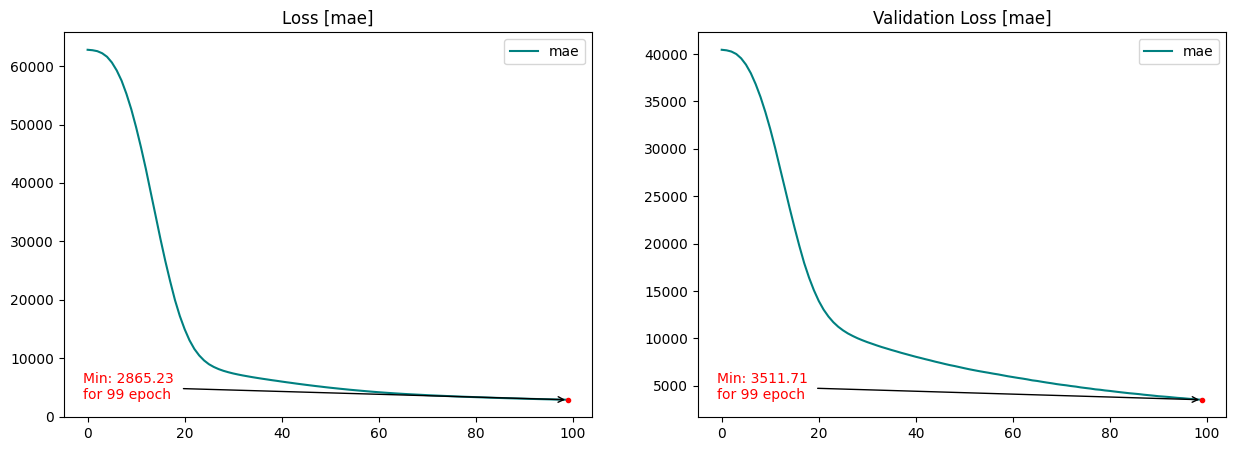

In [31]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Metrics:",results)
for index, metric in enumerate(metrics):
    print(f"{metric} = {results[index+1]}")

from matplotlib import pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(15,5))

min_loss_idx = history.history['loss'].index(min(history.history['loss']))
min_loss = min(history.history['loss'])# Get the lowest  value
ax[0].plot(history.history['loss'], color='teal', label='mae')
# ax[0].plot(history.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss [mae]')
ax[0].legend()
ax[0].annotate(f'Min: {min_loss:.2f} \nfor {min_loss_idx} epoch', 
               xy=(min_loss_idx, min_loss), 
               xytext=(min_loss_idx - 100, min_loss + 100),  # Adjust text position
               arrowprops=dict(facecolor='red', arrowstyle="->"),
               color='red')
ax[0].plot(min_loss_idx, min_loss, 'ro',markersize=3)# Plot a dot at the minimum point


min_val_loss_idx = history.history['val_loss'].index(min(history.history['val_loss']))# Find the index of the minimum 
min_val_loss = min(history.history['val_loss'])# Get the lowest  value
ax[1].plot(history.history['val_loss'], color='teal', label='mae')
# ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Validation Loss [mae]')
ax[1].legend()
# Annotate the lowest point on the validation loss curve
ax[1].annotate(f'Min: {min_val_loss:.2f} \nfor {min_val_loss_idx} epoch', 
               xy=(min_val_loss_idx, min_val_loss), 
               xytext=(min_val_loss_idx - 100, min_val_loss + 100),  # Adjust text position
               arrowprops=dict(facecolor='red', arrowstyle="->"),
               color='red')
ax[1].plot(min_val_loss_idx, min_val_loss, 'ro', markersize=3)# Plot a dot at the minimum point

# ax[2].plot(history.history['val_mse'], color='teal', label='regress loss')
# # ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
# ax[2].title.set_text('Validation mse')
# ax[2].legend()

plt.show()

In [32]:

# print(f'predicted: {predictions[0][0]:.2f} {predictions[0][1]:.2f} {predictions[0][2]:.2f}')
# print(f'true:      {y_test[0][0]:.2f} {y_test[0][1]:.2f} {y_test[0][2]:.2f}')
# print(f'Article: {y_test_nested.iloc[0,0]}, Figure nb: {y_test_nested.iloc[0,1]} Sample name: {y_test_nested.iloc[0,2]}')
# print(y_test_nested.loc[0,['Article_name']])

[2.9772374e-30 2.3750003e-23 2.9814697e-27 1.6495538e+02 8.0622728e-24
 2.5236264e+02 8.5710150e-26 2.6680771e+02 1.0621481e-26 2.8048990e+02
 1.5985619e-23 2.9447998e+02 6.6236346e-22 3.0748978e+02 5.7891415e-25
 3.2172281e+02 6.8709804e-23 3.3184302e+02 1.3424635e-22 3.4274500e+02
 2.9779937e-18 3.5395731e+02 6.0928437e-20 3.6263202e+02 1.5498284e-16
 3.7277606e+02 9.7137883e-02 3.8372650e+02 8.9283802e-02 3.9300446e+02
 9.7260475e-02 4.0126093e+02 1.4595839e-01 4.0969928e+02 2.4398604e-01
 4.1720880e+02 3.0626941e-01 4.2655399e+02 3.2107028e-01 4.3380038e+02
 3.4778956e-01 4.4171796e+02 3.8660315e-01 4.4864630e+02 4.1396618e-01
 4.5480624e+02 4.4589394e-01 4.6038486e+02 4.7854522e-01 4.6559363e+02
 5.0358194e-01 4.7063980e+02 5.4491103e-01 4.7552527e+02 5.7944620e-01
 4.7999530e+02 6.1432493e-01 4.8428229e+02 6.3840288e-01 4.8829111e+02
 6.7330301e-01 4.9251611e+02 6.5437096e-01 4.9739362e+02 5.8830476e-01
 5.0243832e+02 6.2219089e-01 5.0777322e+02 7.2744685e-01 5.1319366e+02
 8.262

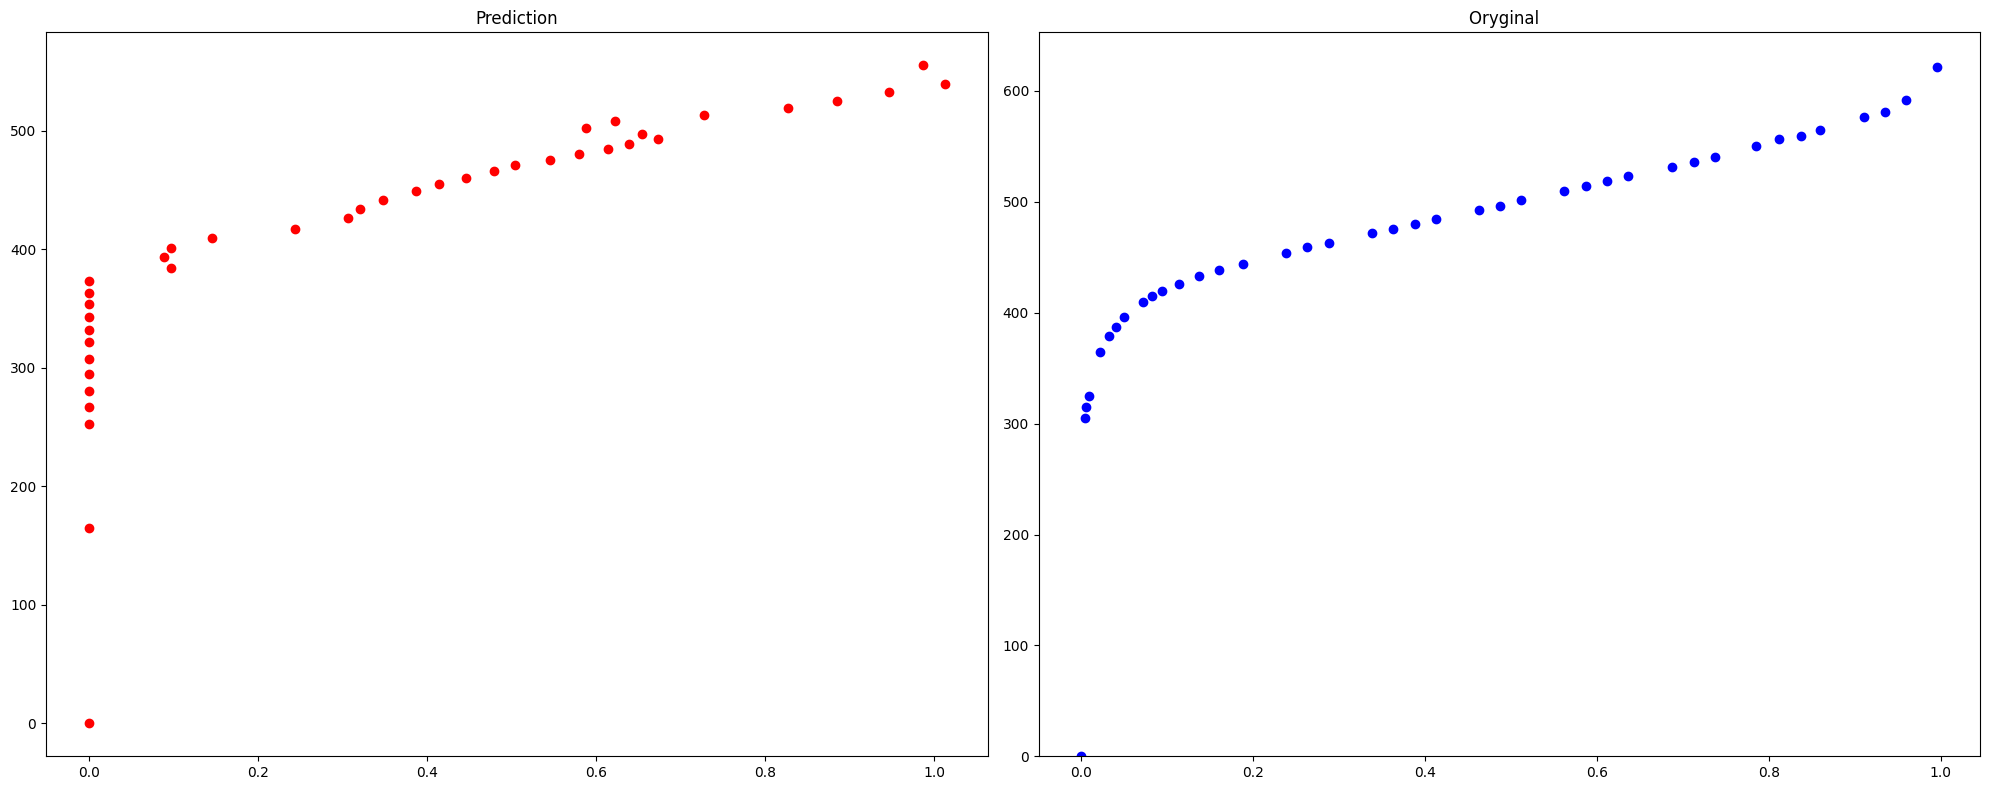

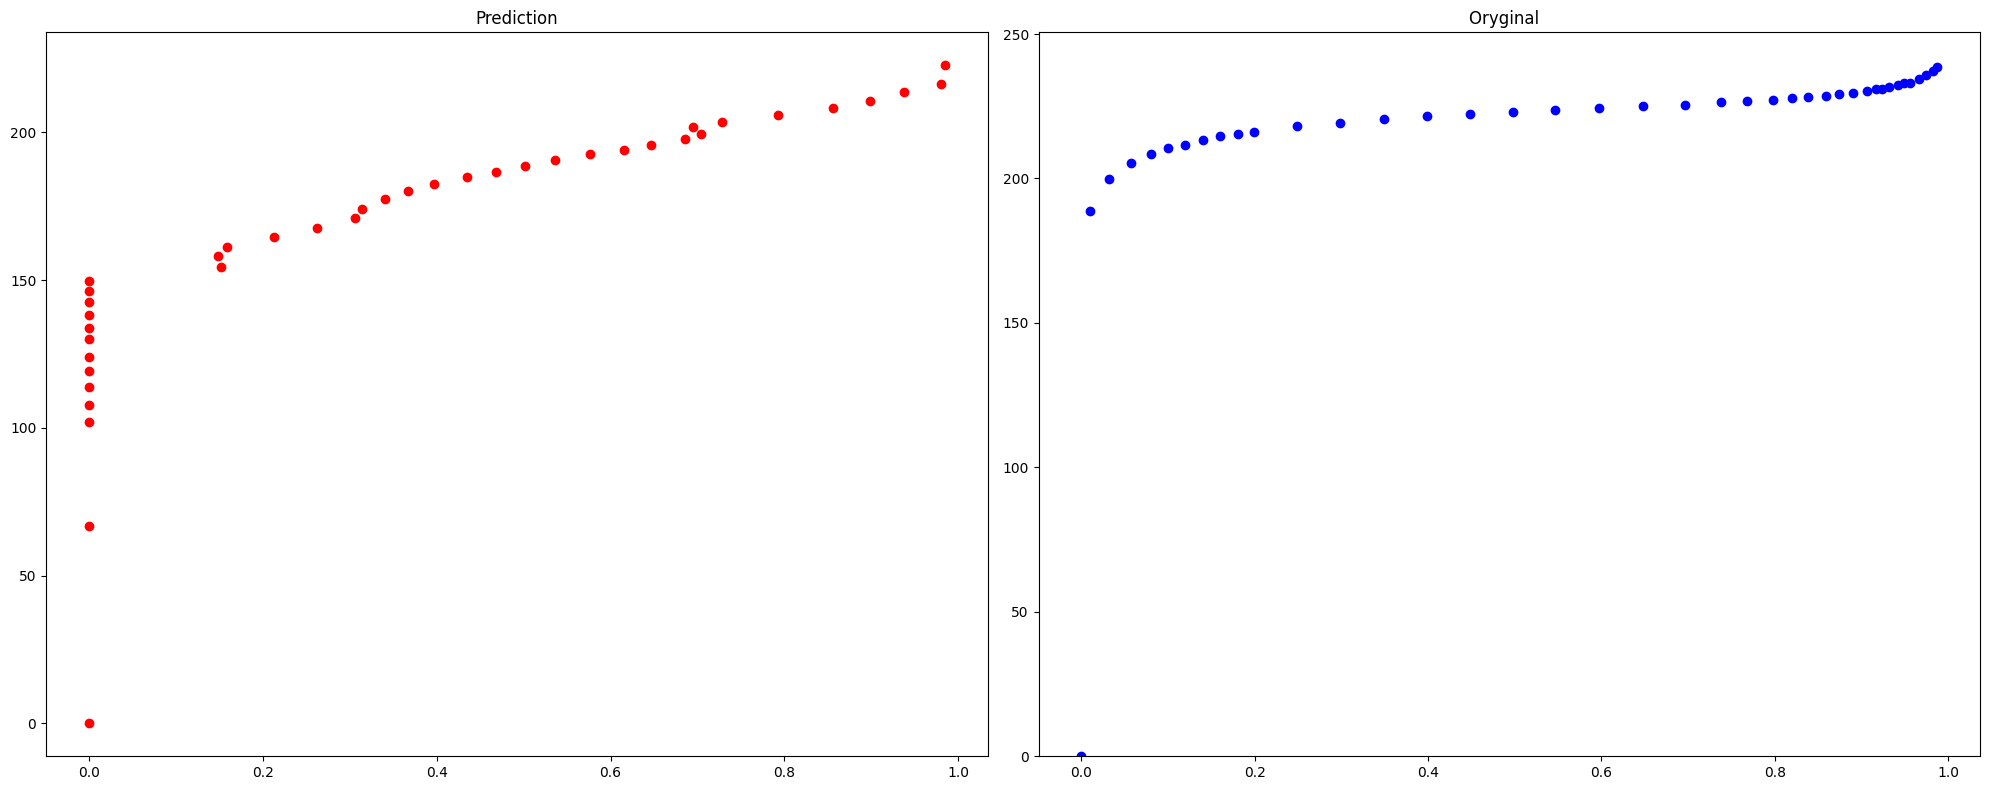

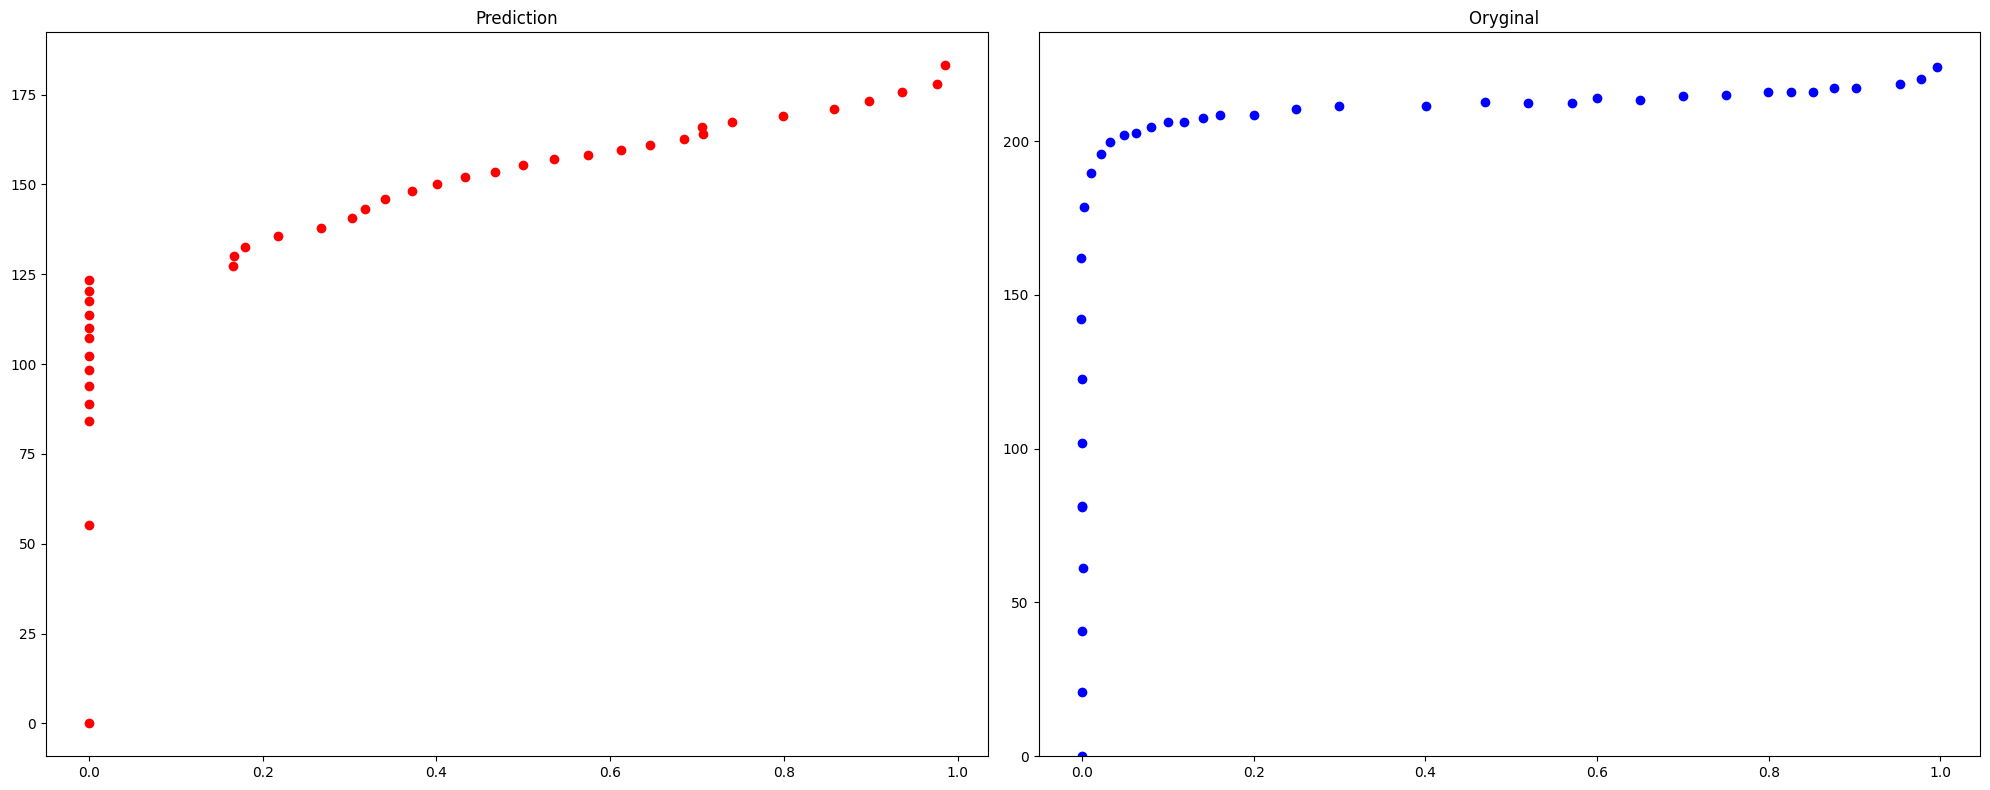

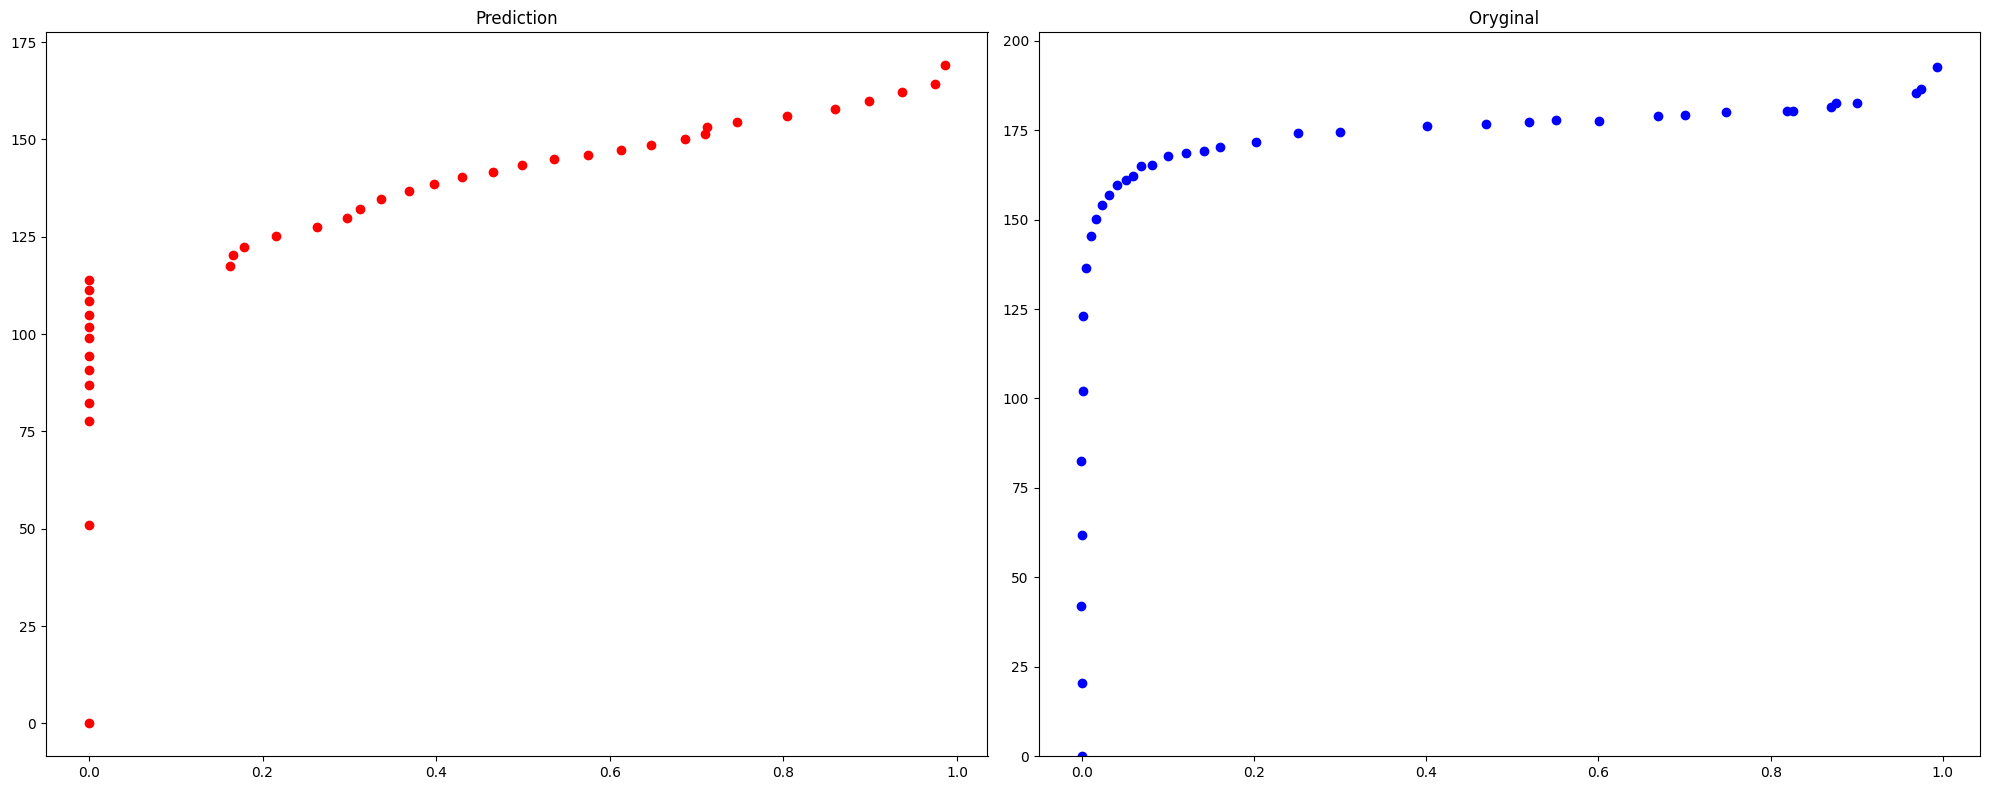

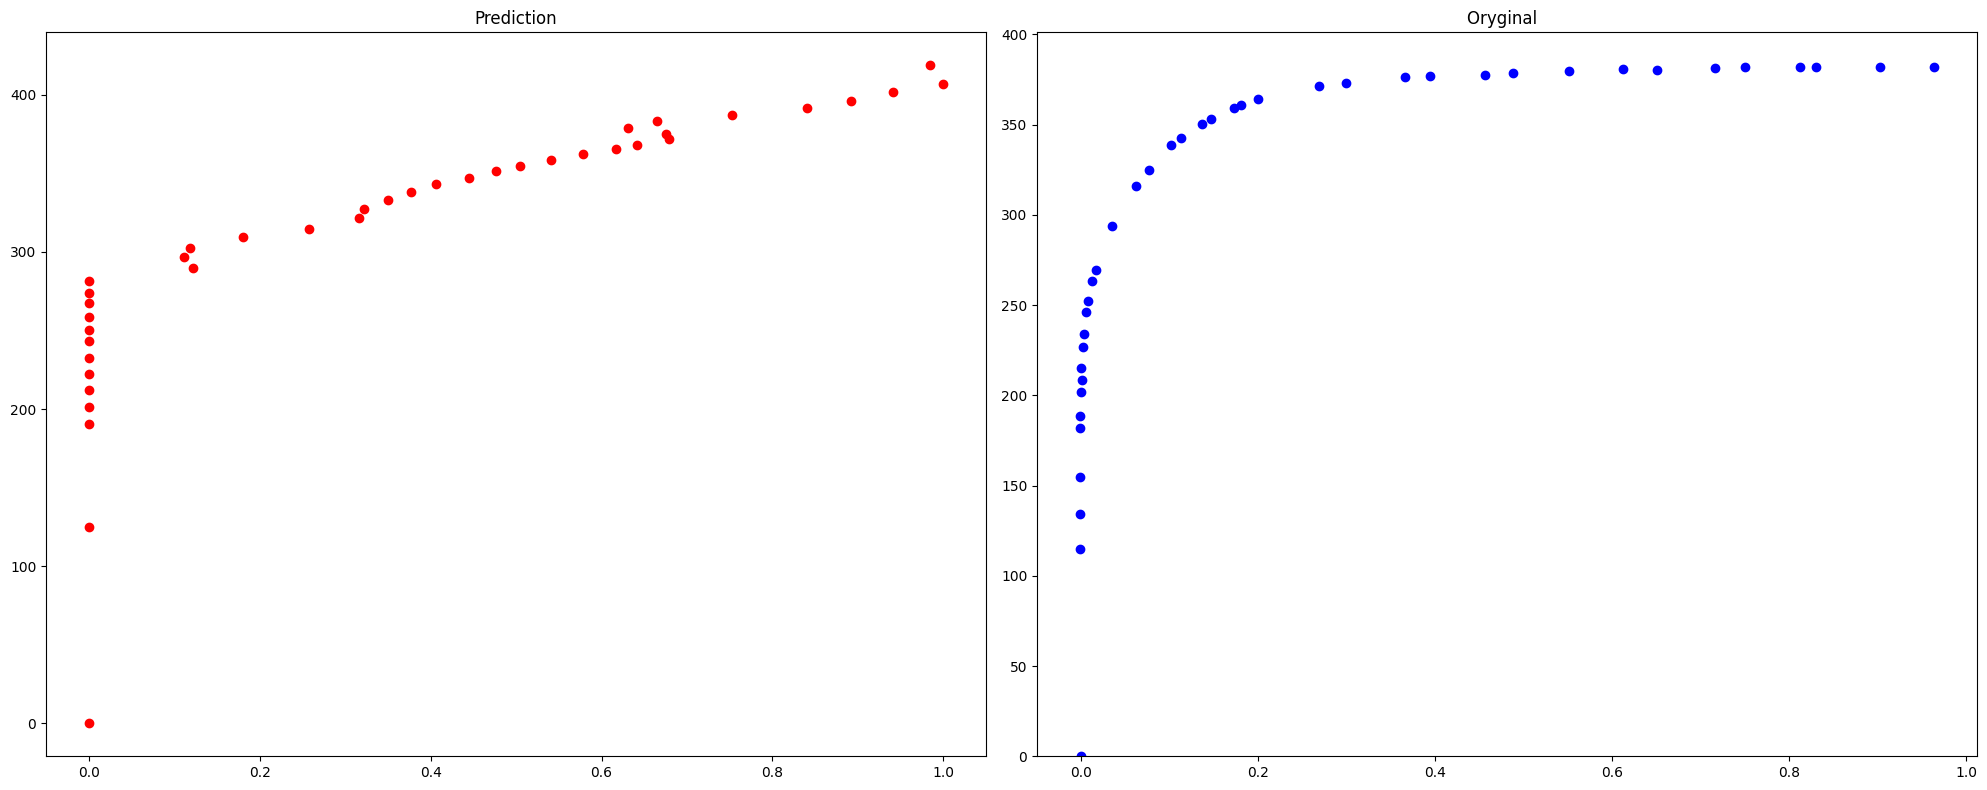

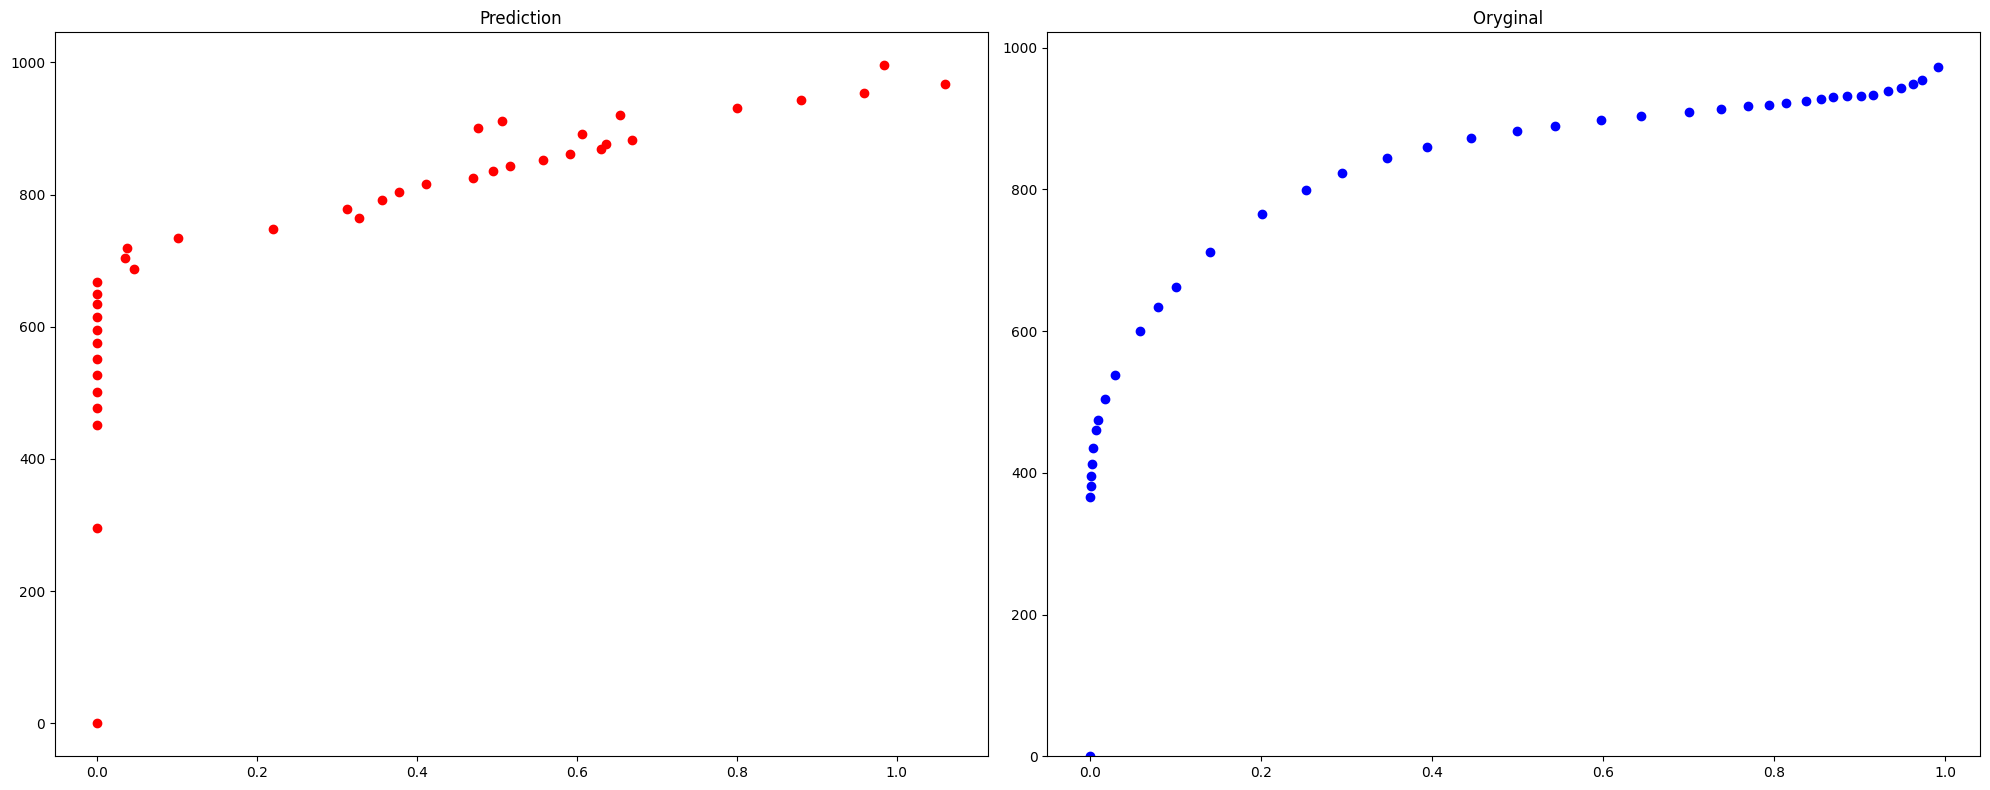

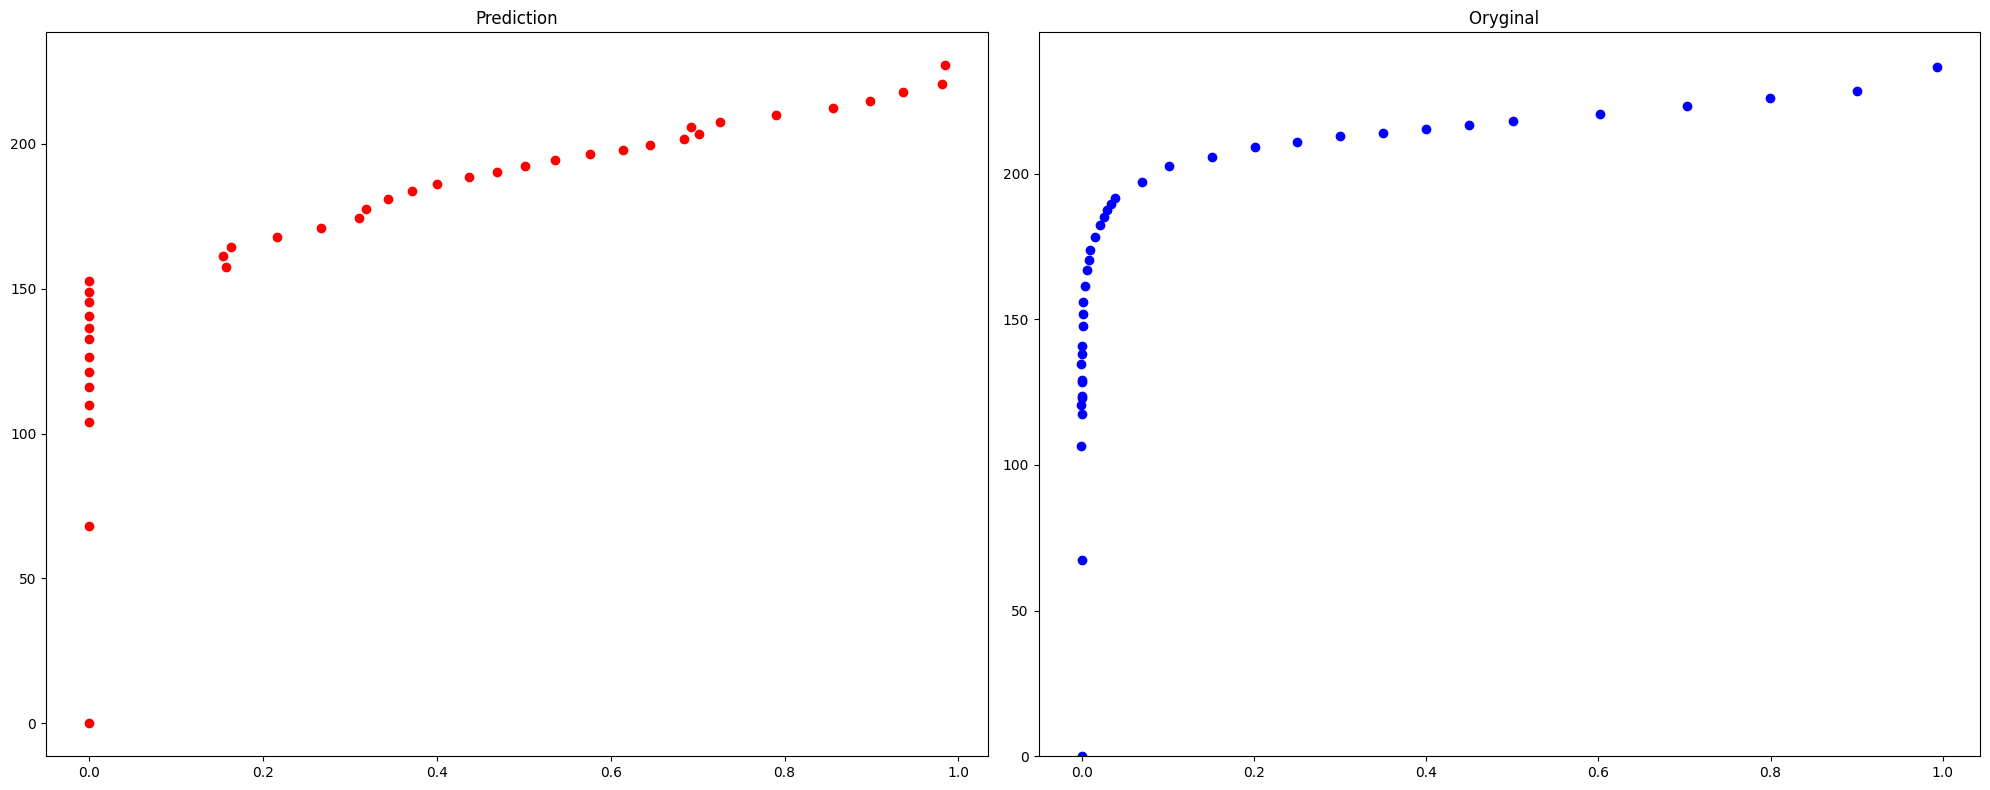

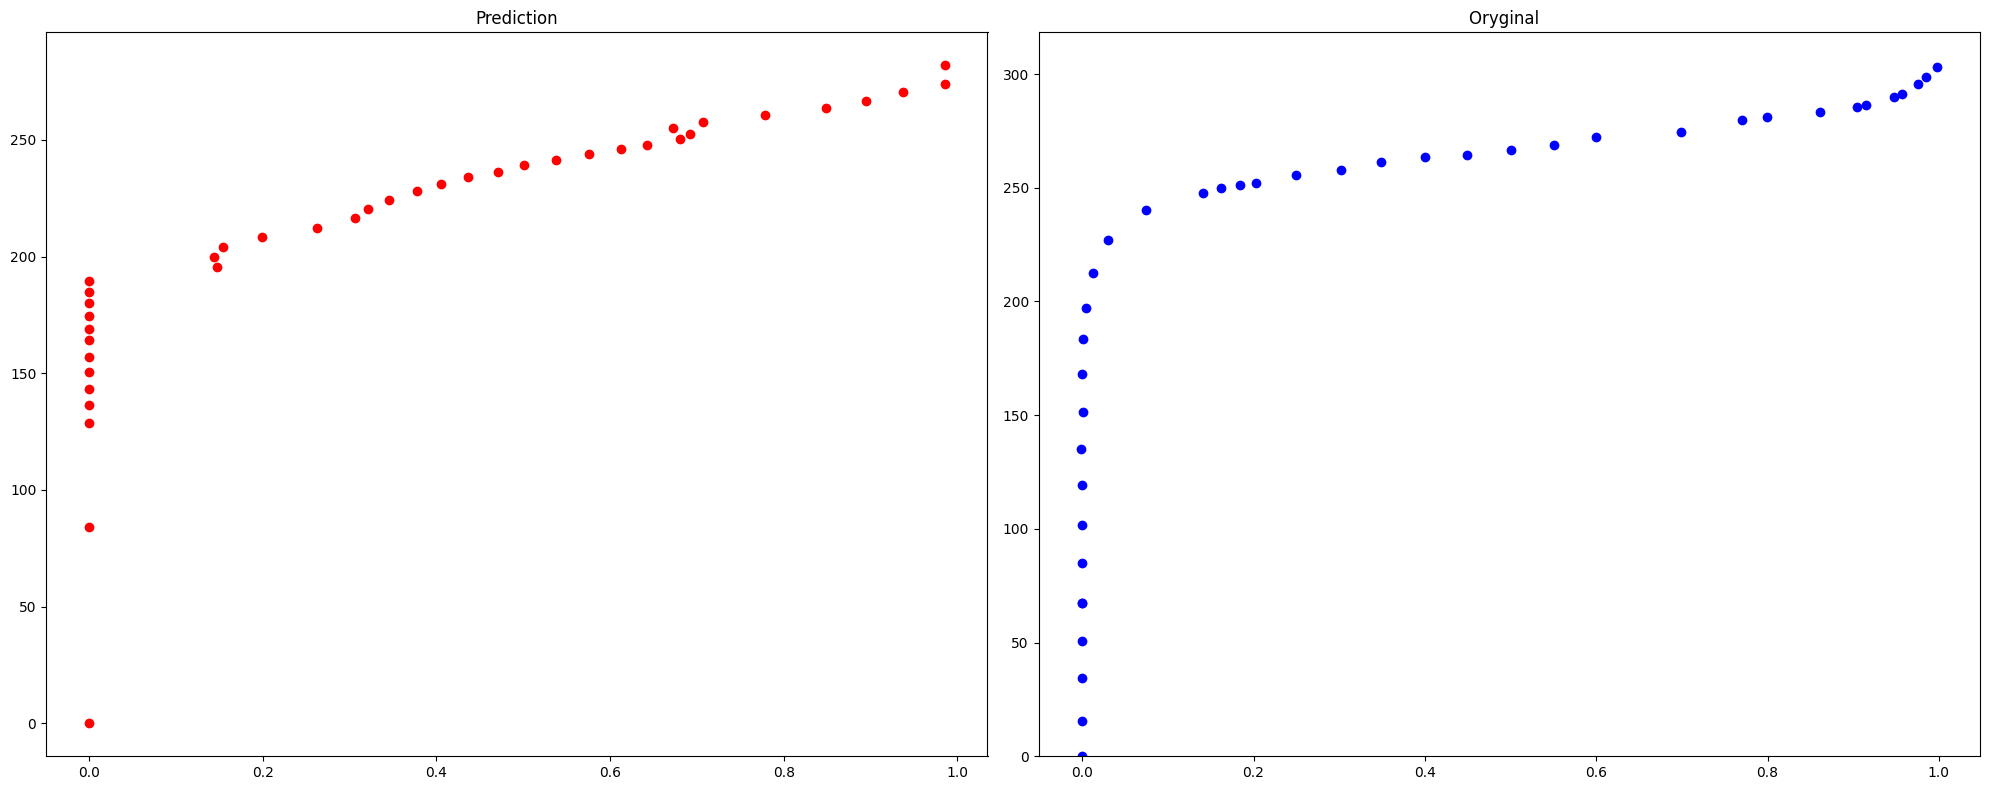

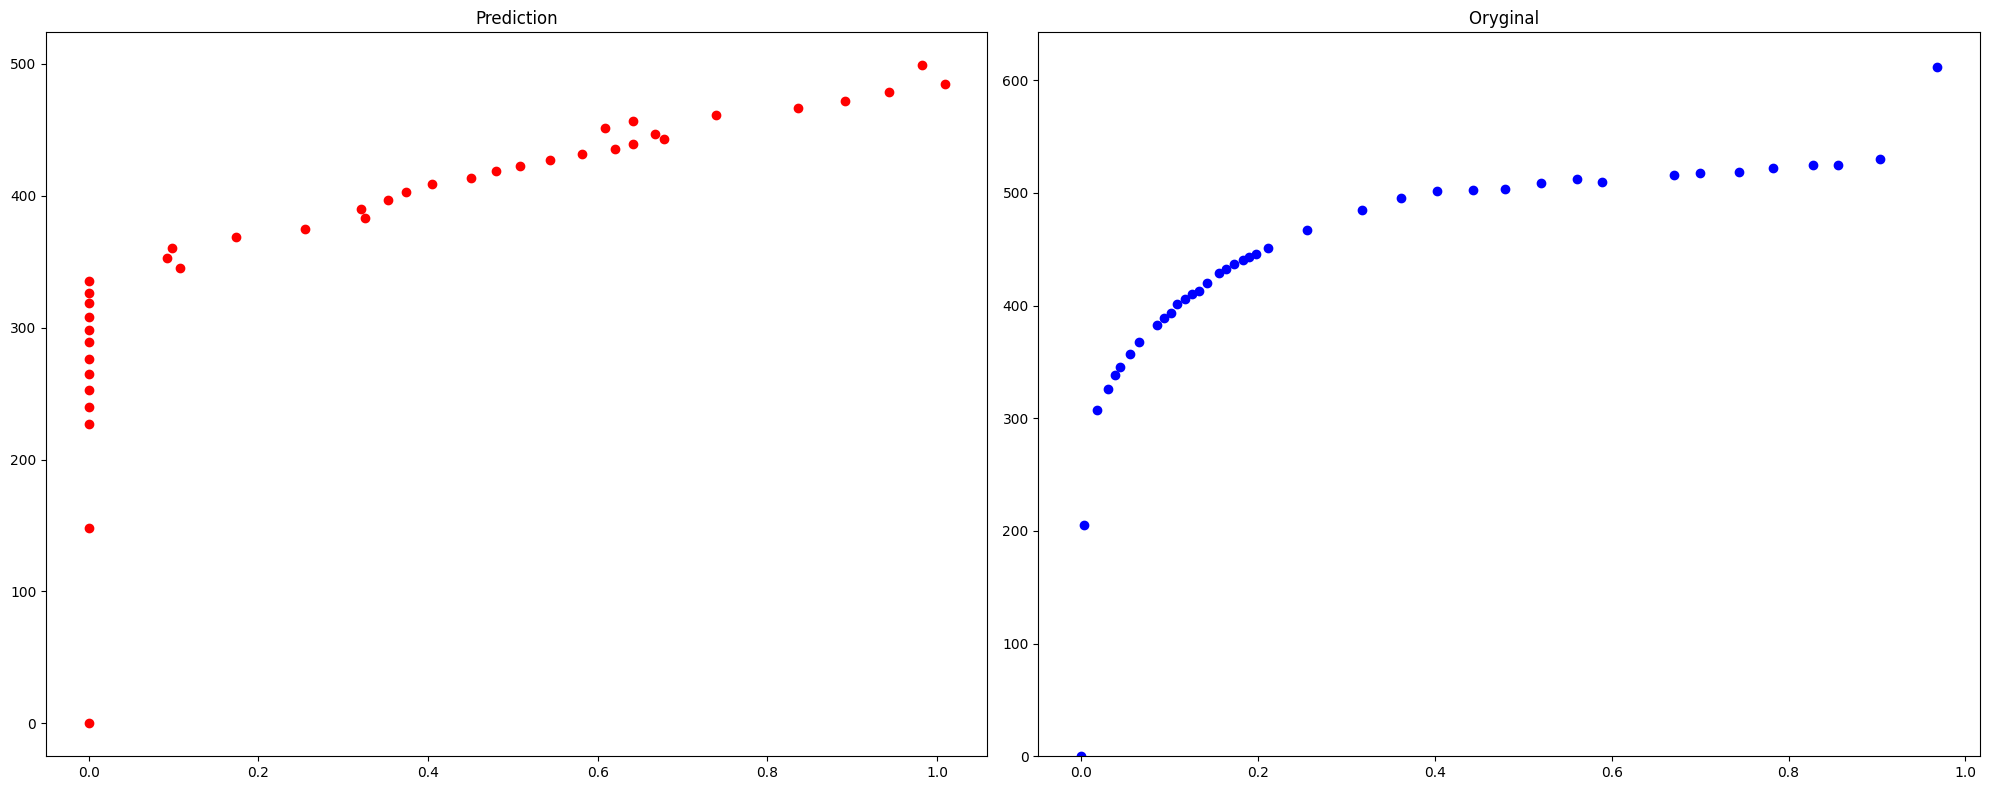

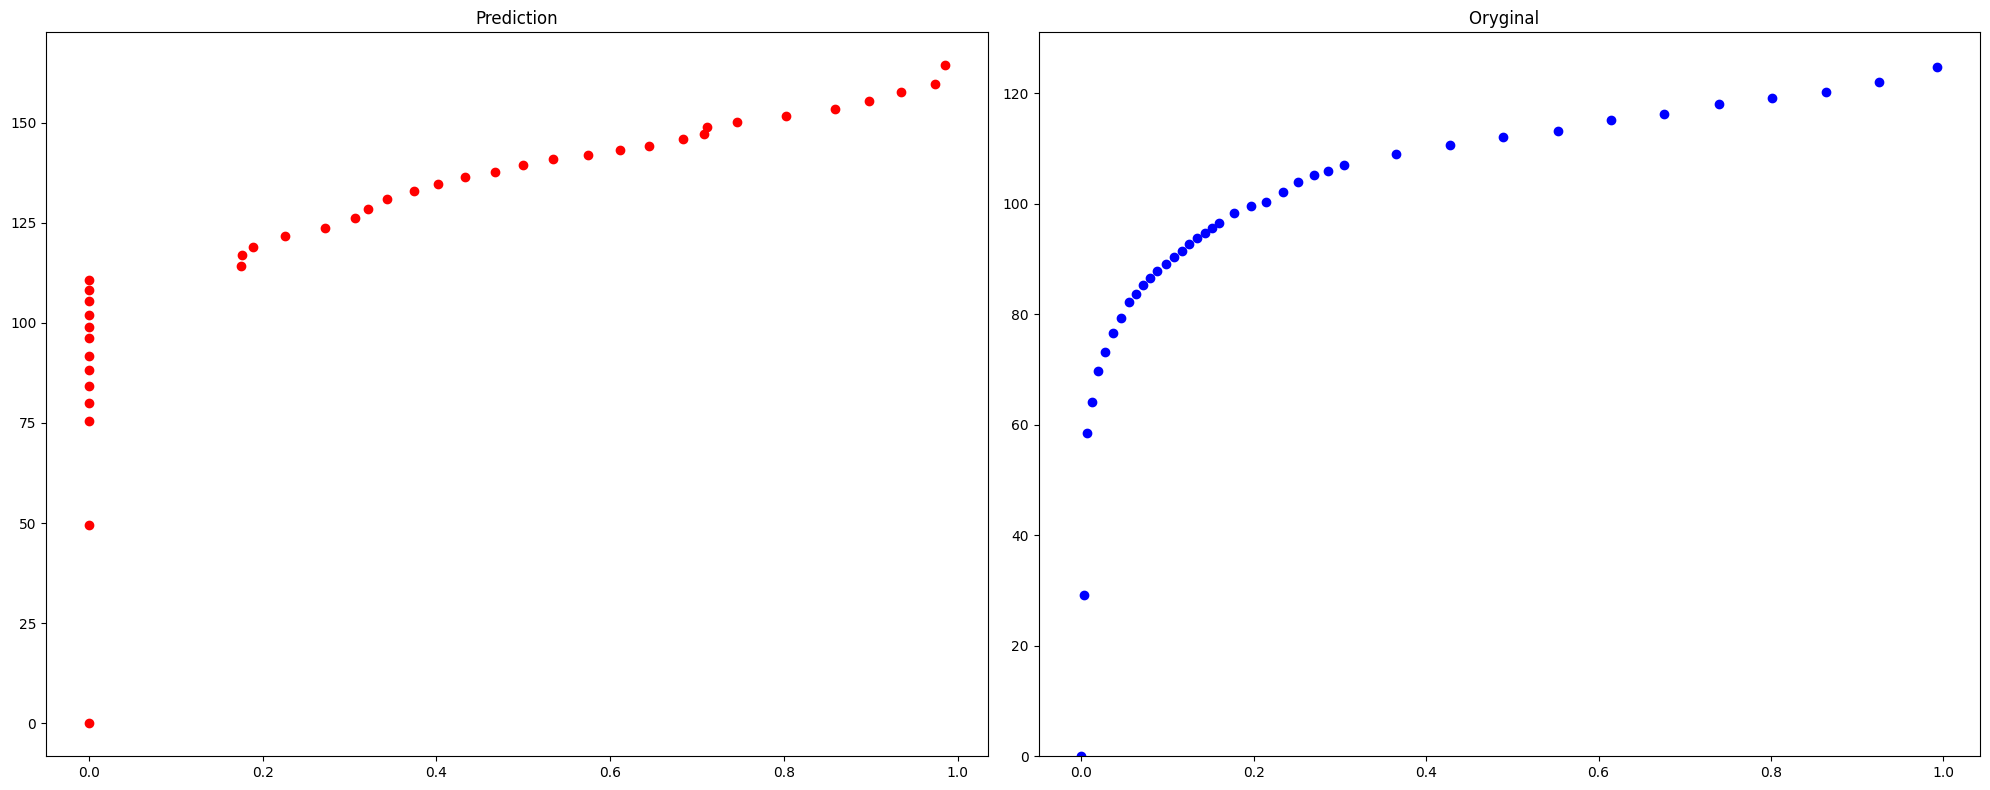

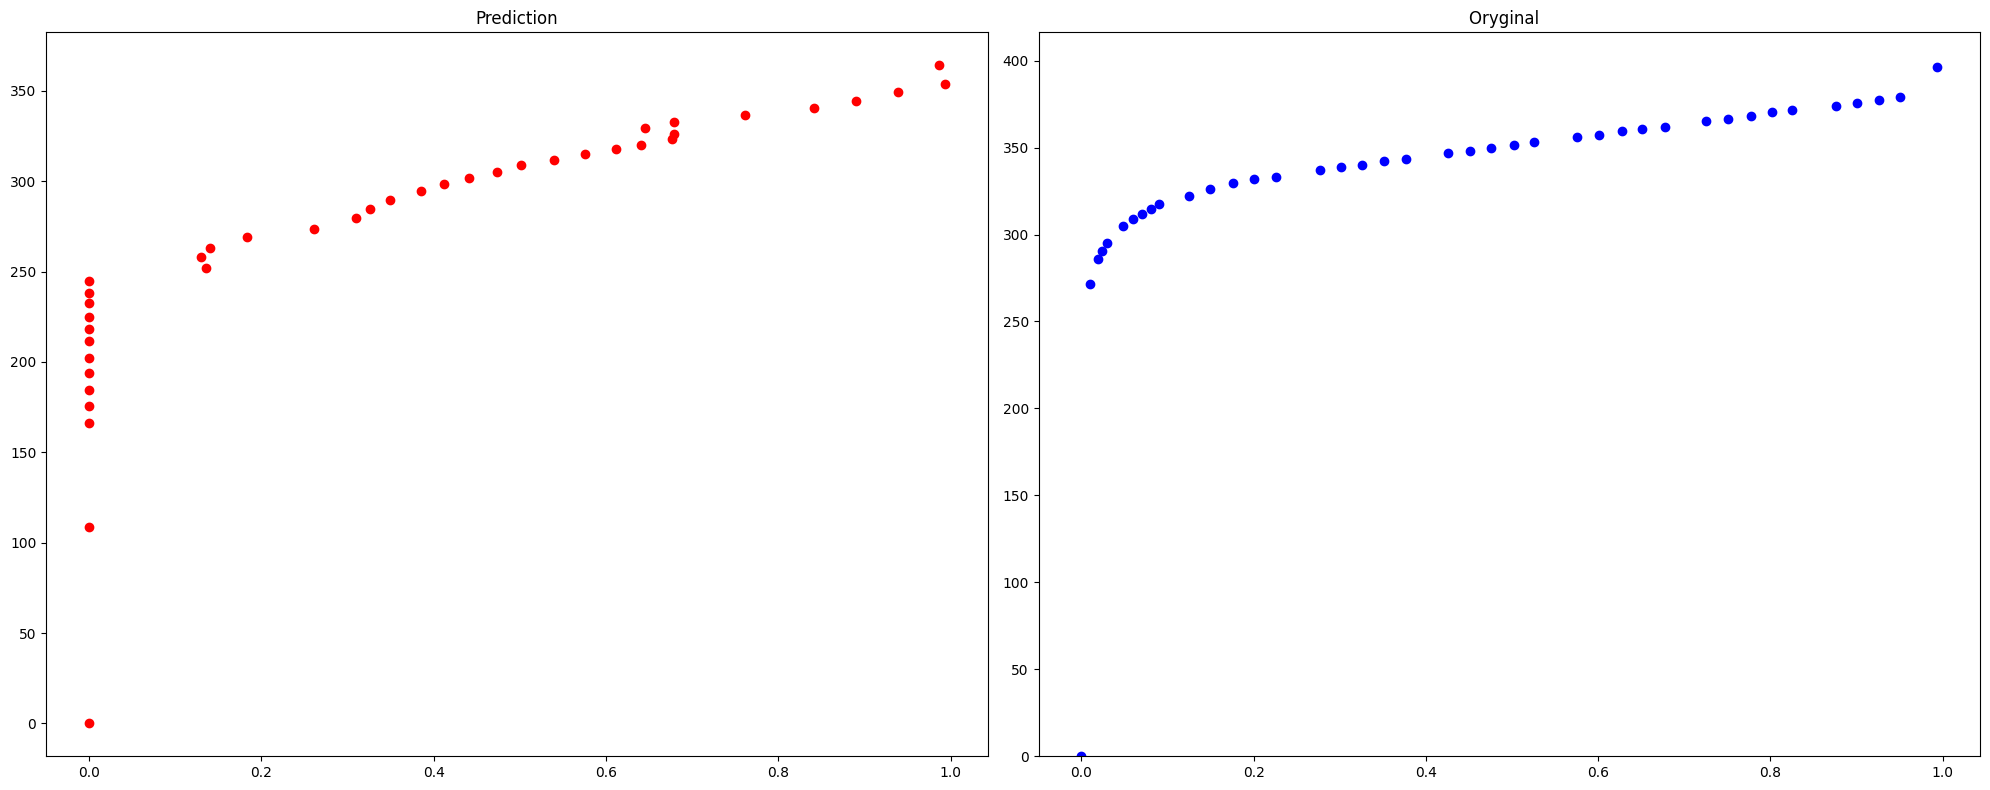

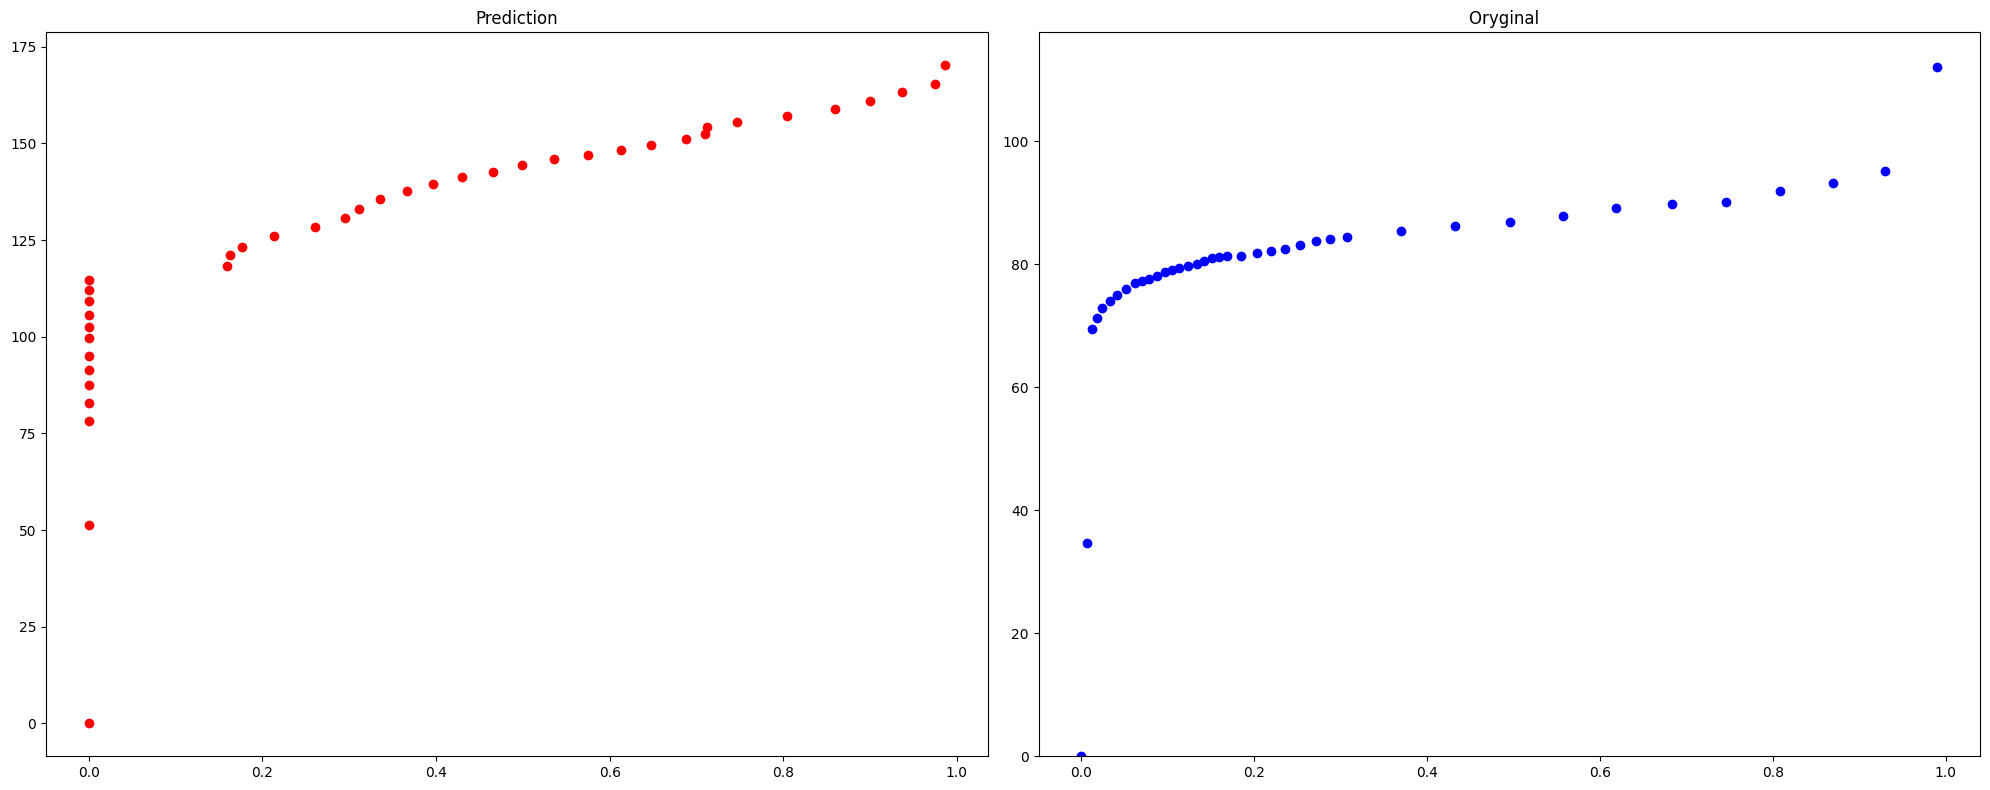

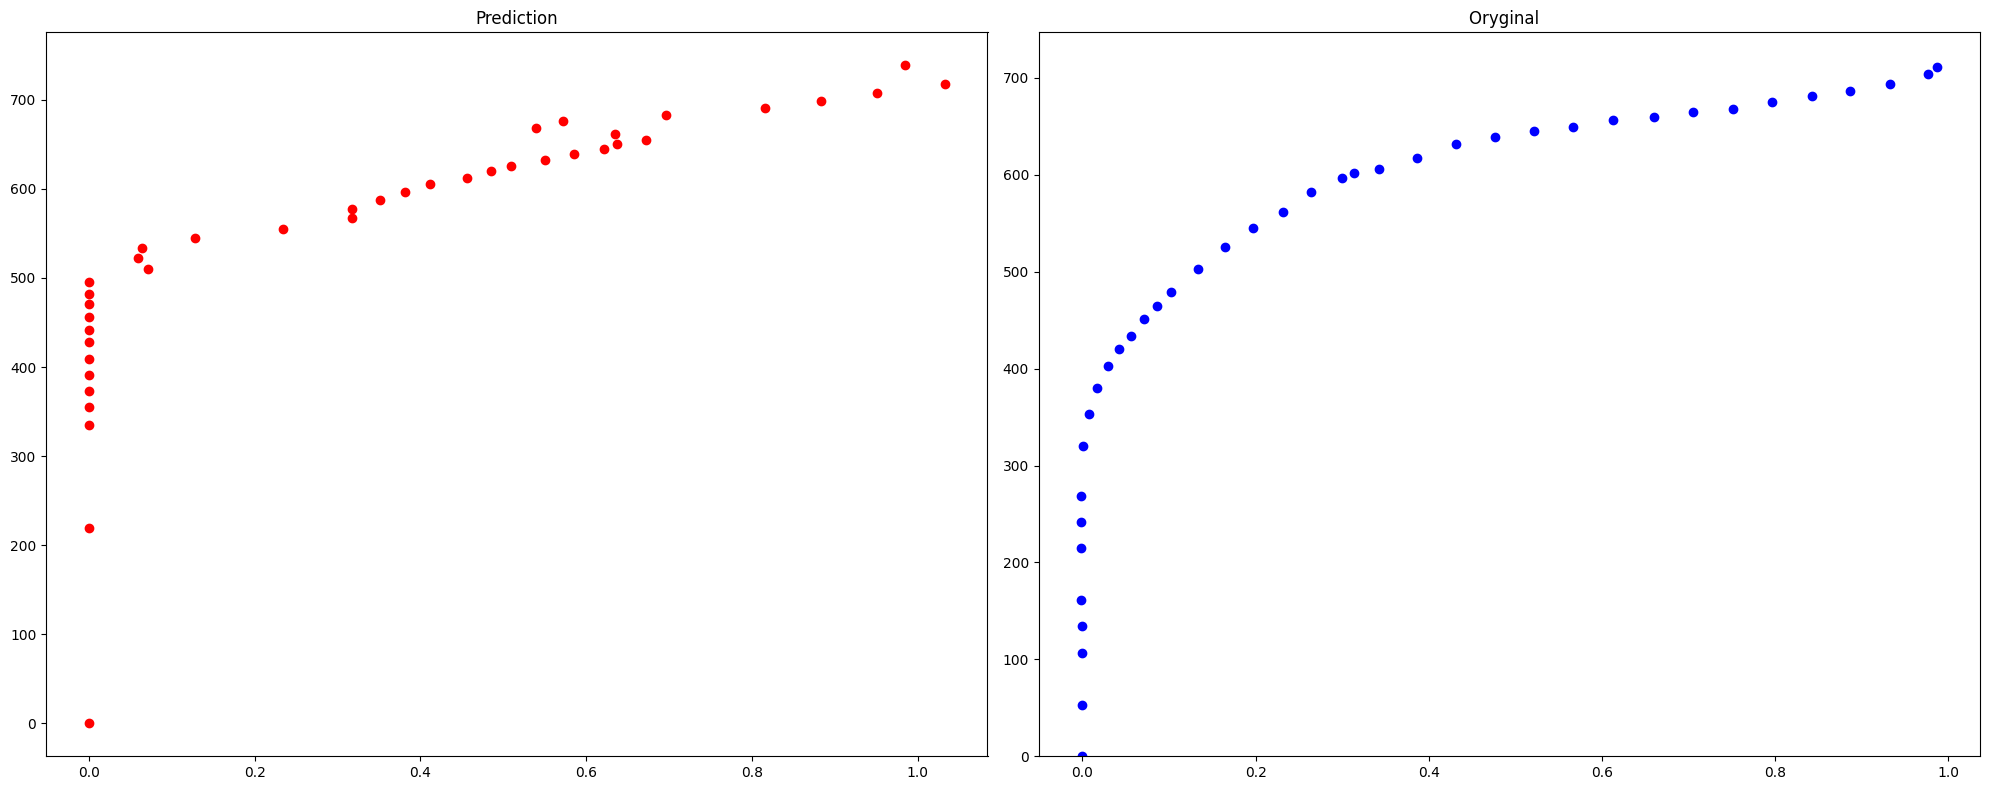

In [33]:
predictions = model.predict(X_test, verbose=0)
print(predictions[0])
for i in range(len(predictions)):

    one_iso = predictions[i]
    one_iso_v2 = one_iso.reshape(size, 2)

    one_iso_true = y_test[i]
    one_iso_true_v2 = one_iso_true.reshape(size, 2)
    
    x1 = one_iso_v2[:, 0]
    y1 = one_iso_v2[:, 1]
    
    x2 = one_iso_true_v2[:, 0]
    y2 = one_iso_true_v2[:, 1]
    
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 8)) #wide, tall

    axs[0].scatter(x1, y1, c='r', label='Dane 1')
    axs[0].set_title(f'Prediction')
    
    
    axs[1].scatter(x2, y2, c='b', label='Dane 2')
    axs[1].set_title(f'Oryginal  ')
    # axs[1].text(0.1, 1.1, f"{info[index][0]}  ->  BET: {y[index]} , sample: {info[index][1]}  graph: {info[index][2]}", horizontalalignment='center', verticalalignment='center',fontsize=14, transform=axs[0].transAxes)
    axs[1].set_ylim(0)
        
    plt.tight_layout()
    plt.show()
    print()

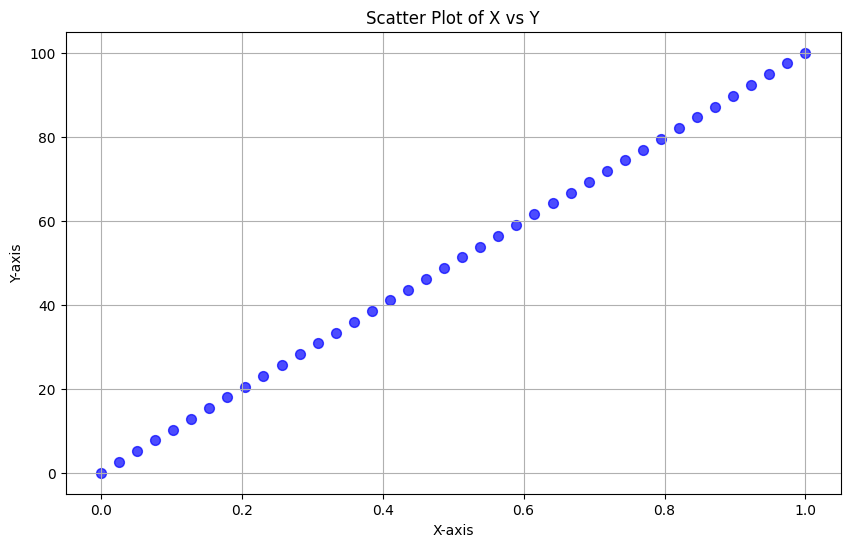

[0.         0.02564103 0.05128205 0.07692308 0.1025641  0.12820513
 0.15384615 0.17948718 0.20512821 0.23076923 0.25641026 0.28205128
 0.30769231 0.33333333 0.35897436 0.38461538 0.41025641 0.43589744
 0.46153846 0.48717949 0.51282051 0.53846154 0.56410256 0.58974359
 0.61538462 0.64102564 0.66666667 0.69230769 0.71794872 0.74358974
 0.76923077 0.79487179 0.82051282 0.84615385 0.87179487 0.8974359
 0.92307692 0.94871795 0.97435897 1.        ]
[  0.           2.56410256   5.12820513   7.69230769  10.25641026
  12.82051282  15.38461538  17.94871795  20.51282051  23.07692308
  25.64102564  28.20512821  30.76923077  33.33333333  35.8974359
  38.46153846  41.02564103  43.58974359  46.15384615  48.71794872
  51.28205128  53.84615385  56.41025641  58.97435897  61.53846154
  64.1025641   66.66666667  69.23076923  71.79487179  74.35897436
  76.92307692  79.48717949  82.05128205  84.61538462  87.17948718
  89.74358974  92.30769231  94.87179487  97.43589744 100.        ]


In [36]:
x = np.linspace(0, 1, 40)
y = np.linspace(0, 100, 40)

import matplotlib.pyplot as plt
import numpy as np
# Extract x and y coordinates
# x = one_iso_v2[:, 0]
# y = one_iso_v2[:, 1]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=50, alpha=0.7, color='blue')

# Set labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot of X vs Y')

# Show grid and plot
plt.grid(True)
plt.show()


print(x)
print(y)

In [114]:
x = np.linspace(0, 1, 40)

one_iso_true = y_test[0]
one_iso_true_v2 = one_iso_true.reshape(size, 2)
x2 = one_iso_true_v2[:, 0]
y2 = one_iso_true_v2[:, 1]


data_do_podzialu_na_przedzialy_oś_x = x2
data_do_podzialu_na_przedzialy_oś_y = y2
data  = []
counter = 0
poprzednia = 0
new_x = [] # końcowy zestaw x

for liczba in x:
    if(liczba != 0.0 and liczba != 1.0):
        new_x.append(liczba)
        counter = counter+1
        # print(f'{counter}     {poprzednia}<x<{liczba}')
        suma = []
        for i in range(len(data_do_podzialu_na_przedzialy_oś_x)):
            if(poprzednia<data_do_podzialu_na_przedzialy_oś_x[i]<liczba):
                suma.append(data_do_podzialu_na_przedzialy_oś_y[i])
        data.append(np.mean(suma))   
        poprzednia = liczba
print(data)

# wypelnianie pojedzynczych nan
new_data = []
for index, e in enumerate(data):
    # print(f'{index}  -  {e}')
    if np.isnan(e) and (not np.isnan(data[index-1])) and (not np.isnan(data[index+1])):
        if index != 0:
            if not np.isnan(data[index-1]):
                index_przed = index - 1
            if not np.isnan(data[index+1]):
                index_po = index + 1
                new_men = (np.mean( (data[index_przed] + data[index_po]) ) / 2) 
                new_data.append(new_men)
    else:
        new_data.append(e)

# for index, e in enumerate(new_data):
#     print(f'{index}  -  {e}')


# wypelnianie zbiorowych nan
poczatek_i_koniec_zbioru = []
tymczasowe_mini_zbiory = []
for index, e in enumerate(new_data):
    print(f'{index}  -  {e}')
    if len(poczatek_i_koniec_zbioru) == 0 :
            if np.isnan(e) and (not np.isnan(data[index-1])) and (np.isnan(data[index+1])):
                poczatek_i_koniec_zbioru.append(index)
                print(f"pierwszy index dla [{index}] - len(poczatek_i_koniec_zbioru) {len(poczatek_i_koniec_zbioru)}")
    if len(poczatek_i_koniec_zbioru) == 1 :
            if np.isnan(e):
                tymczasowe_mini_zbiory.append(index)
            if np.isnan(e) and (np.isnan(data[index-1])) and (not np.isnan(data[index+1])):
                poczatek_i_koniec_zbioru.append(index)
                print(f"drugi index dla [{index}] - len(poczatek_i_koniec_zbioru) {len(poczatek_i_koniec_zbioru)}")

    if len(poczatek_i_koniec_zbioru) == 2 :
        # print(f"of {poczatek_i_koniec_zbioru[0]} do {poczatek_i_koniec_zbioru[1]}")
        roznica = (new_data[poczatek_i_koniec_zbioru[1] + 1] - new_data[poczatek_i_koniec_zbioru[0] - 1])
        ile_dodac = roznica / (len(tymczasowe_mini_zbiory)+1)
        print(f'------------------------------------ roznica {roznica} ile_dodac {ile_dodac}')
        for inde in tymczasowe_mini_zbiory:
            new_data[inde] = new_data[inde-1] + ile_dodac
            # print(f'index: {inde}')
        poczatek_i_koniec_zbioru = []
        tymczasowe_mini_zbiory = []
    # if len(poczatek_i_koniec_zbioru) == 0 :
        
    # if np.isnan(e) and (not np.isnan(data[index-1])) and (np.isnan(data[index+1])):
    #     poczatek_i_koniec_zbioru.append(data[index])
    #     if index != 0:
    #         if not np.isnan(data[index-1]):
    #             index_przed = index - 1
    #         if not np.isnan(data[index+1]):
    #             index_po = index + 1
    #             new_men = np.mean( (data[index_przed] + data[index_po]) )
    #             new_data.append(new_men)
    # else:
    #     new_data.append(e)

for index, e in enumerate(new_data):
    print(f'{index}  -  {e}')


[np.float64(327.34976887519264), np.float64(387.21109399075505), np.float64(409.3220338983051), np.float64(417.14175654853625), np.float64(425.5007704160247), np.float64(433.0508474576272), np.float64(438.4437596302003), np.float64(444.37596302003084), np.float64(nan), np.float64(454.08320493066265), np.float64(458.9368258859785), np.float64(463.2511556240371), np.float64(nan), np.float64(471.87981510015425), np.float64(475.6548536209554), np.float64(479.9691833590139), np.float64(484.2835130970725), np.float64(nan), np.float64(494.53004622496155), np.float64(501.5408320493067), np.float64(nan), np.float64(510.1694915254239), np.float64(514.4838212634825), np.float64(518.7981510015409), np.float64(523.1124807395995), np.float64(nan), np.float64(531.2018489984592), np.float64(536.0554699537751), np.float64(540.909090909091), np.float64(nan), np.float64(550.0770416024654), np.float64(556.5485362095533), np.float64(559.7842835130972), np.float64(565.1771956856703), np.float64(nan), np.flo

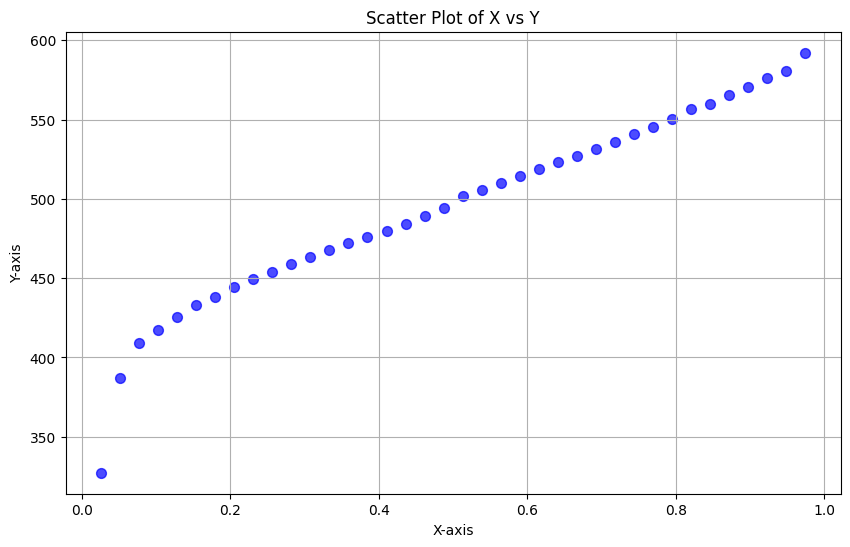

[np.float64(0.02564102564102564), np.float64(0.05128205128205128), np.float64(0.07692307692307693), np.float64(0.10256410256410256), np.float64(0.1282051282051282), np.float64(0.15384615384615385), np.float64(0.1794871794871795), np.float64(0.20512820512820512), np.float64(0.23076923076923075), np.float64(0.2564102564102564), np.float64(0.28205128205128205), np.float64(0.3076923076923077), np.float64(0.3333333333333333), np.float64(0.358974358974359), np.float64(0.3846153846153846), np.float64(0.41025641025641024), np.float64(0.4358974358974359), np.float64(0.4615384615384615), np.float64(0.48717948717948717), np.float64(0.5128205128205128), np.float64(0.5384615384615384), np.float64(0.5641025641025641), np.float64(0.5897435897435898), np.float64(0.6153846153846154), np.float64(0.641025641025641), np.float64(0.6666666666666666), np.float64(0.6923076923076923), np.float64(0.717948717948718), np.float64(0.7435897435897436), np.float64(0.7692307692307692), np.float64(0.7948717948717948), 

In [115]:
import matplotlib.pyplot as plt
import numpy as np
# Extract x and y coordinates
# x = one_iso_v2[:, 0]
# y = one_iso_v2[:, 1]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(new_x, new_data, s=50, alpha=0.7, color='blue')

# Set labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot of X vs Y')

# Show grid and plot
plt.grid(True)
plt.show()


print(new_x)
print(new_data)

new_x[np.float64(0.02564102564102564), np.float64(0.05128205128205128), np.float64(0.07692307692307693), np.float64(0.10256410256410256), np.float64(0.1282051282051282), np.float64(0.15384615384615385), np.float64(0.1794871794871795), np.float64(0.20512820512820512), np.float64(0.23076923076923075), np.float64(0.2564102564102564), np.float64(0.28205128205128205), np.float64(0.3076923076923077), np.float64(0.3333333333333333), np.float64(0.358974358974359), np.float64(0.3846153846153846), np.float64(0.41025641025641024), np.float64(0.4358974358974359), np.float64(0.4615384615384615), np.float64(0.48717948717948717), np.float64(0.5128205128205128), np.float64(0.5384615384615384), np.float64(0.5641025641025641), np.float64(0.5897435897435898), np.float64(0.6153846153846154), np.float64(0.641025641025641), np.float64(0.6666666666666666), np.float64(0.6923076923076923), np.float64(0.717948717948718), np.float64(0.7435897435897436), np.float64(0.7692307692307692), np.float64(0.79487179487179

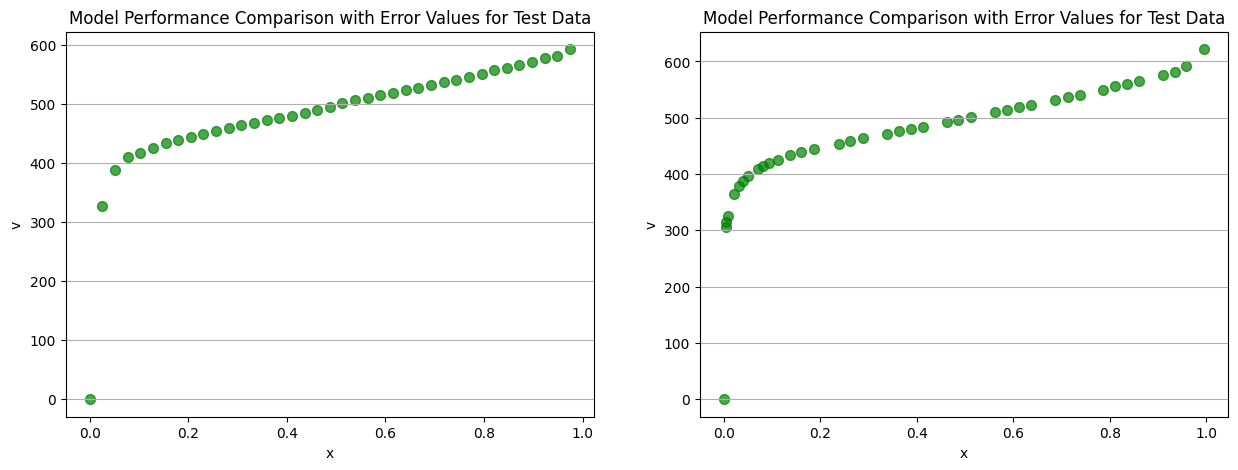

In [118]:
fig, ax = plt.subplots(ncols=2, figsize=(15,5))

print(f"new_x{new_x} new_data {new_data}")

# Example array
new_x = np.array(new_x)
new_x = np.insert(new_x, 0, 0)# Insert 0 at the beginning

new_data = np.array(new_data)
new_data = np.insert(new_data, 0, 0)

ax[0].scatter(new_x, new_data, s=50, alpha=0.7, color='g')
ax[0].set_ylabel('v')
ax[0].set_xlabel('x')
ax[0].set_title('Model Performance Comparison with Error Values for Test Data')
ax[0].grid(axis='y')



ax[1].scatter(x2, y2, s=50, alpha=0.7, color='g')
ax[1].set_ylabel('v')
ax[1].set_xlabel('x')
ax[1].set_title('Model Performance Comparison with Error Values for Test Data')
ax[1].grid(axis='y')
plt.show()

In [130]:
for index , bananadata in enumerate(y_test):
    print(f"data nr: {index} bananadata {bananadata}")
    
    x = np.linspace(0, 1, 40)
    one_iso_true = bananadata
    one_iso_true_v2 = one_iso_true.reshape(size, 2)
    x2 = one_iso_true_v2[:, 0]
    y2 = one_iso_true_v2[:, 1]
    
    data_do_podzialu_na_przedzialy_oś_x = x2
    data_do_podzialu_na_przedzialy_oś_y = y2
    data  = []
    counter = 0
    poprzednia = 0
    new_x = [] # końcowy zestaw x
    
    # tworzenie pierwszego zbioru y z wartościami nan 
    for liczba in x:
        if(liczba != 0.0 and liczba != 1.0):
            new_x.append(liczba)
            counter = counter+1
            # print(f'{counter}     {poprzednia}<x<{liczba}')
            suma = []
            for i in range(len(data_do_podzialu_na_przedzialy_oś_x)):
                if(poprzednia<data_do_podzialu_na_przedzialy_oś_x[i]<liczba):
                    suma.append(data_do_podzialu_na_przedzialy_oś_y[i])
            data.append(np.mean(suma))   
            poprzednia = liczba
    # print(data)
    
    # wypelnianie pojedzynczych nan, ale zostają grupki nan
    new_data = []
    for index, e in enumerate(data):
        # print(f'{index}  -  {e}')
        if np.isnan(e) and (not np.isnan(data[index-1])) and (not np.isnan(data[index+1])):
            if index != 0:
                if not np.isnan(data[index-1]):
                    index_przed = index - 1
                if not np.isnan(data[index+1]):
                    index_po = index + 1
                    new_men = (np.mean( (data[index_przed] + data[index_po]) ) / 2) 
                    new_data.append(new_men)
        else:
            new_data.append(e)
    
    # wypelnianie grupek nan i uzyskanie gotowej ostatecznej listy danych
    poczatek_i_koniec_zbioru = []
    tymczasowe_mini_zbiory = []
    for index, e in enumerate(new_data):
        if np.isnan(len(new_data)-1)):
            new_data[index] = max(new_data)
        print(f'{index}  -  {e}')
        if len(poczatek_i_koniec_zbioru) == 0 :
                if np.isnan(e) and (not np.isnan(data[index-1])) and (np.isnan(data[index+1])):
                    poczatek_i_koniec_zbioru.append(index)
                    print(f"pierwszy index dla [{index}] - len(poczatek_i_koniec_zbioru) {len(poczatek_i_koniec_zbioru)}")
        if len(poczatek_i_koniec_zbioru) == 1 :
                if np.isnan(e):
                    tymczasowe_mini_zbiory.append(index)
                if np.isnan(e) and (np.isnan(data[index-1])) and (not np.isnan(data[index+1])):
                    poczatek_i_koniec_zbioru.append(index)
                    print(f"drugi index dla [{index}] - len(poczatek_i_koniec_zbioru) {len(poczatek_i_koniec_zbioru)}")
    
        if len(poczatek_i_koniec_zbioru) == 2 :
            # print(f"of {poczatek_i_koniec_zbioru[0]} do {poczatek_i_koniec_zbioru[1]}")
            roznica = (new_data[poczatek_i_koniec_zbioru[1] + 1] - new_data[poczatek_i_koniec_zbioru[0] - 1])
            ile_dodac = roznica / (len(tymczasowe_mini_zbiory)+1)
            # print(f'------------------------------------ roznica {roznica} ile_dodac {ile_dodac}')
            for inde in tymczasowe_mini_zbiory:
                new_data[inde] = new_data[inde-1] + ile_dodac
                # print(f'index: {inde}')
            poczatek_i_koniec_zbioru = []
            tymczasowe_mini_zbiory = []
    
    # for index, e in enumerate(new_data):
    #     print(f'{index}  -  {e}')

    fig, ax = plt.subplots(ncols=2, figsize=(15,5))
    
    # print(f"new_x{new_x} new_data {new_data}")
    
    # Example array
    new_x = np.array(new_x)
    new_x = np.insert(new_x, 0, 0)# Insert 0 at the beginning
    
    new_data = np.array(new_data)
    new_data = np.insert(new_data, 0, 0)
    
    ax[0].scatter(new_x, new_data, s=50, alpha=0.7, color='g')
    ax[0].set_ylabel('v')
    ax[0].set_xlabel('x')
    ax[0].set_title('Model Performance Comparison with Error Values for Test Data')
    ax[0].grid(axis='y')
    
    
    
    ax[1].scatter(x2, y2, s=50, alpha=0.7, color='g')
    ax[1].set_ylabel('v')
    ax[1].set_xlabel('x')
    ax[1].set_title('Model Performance Comparison with Error Values for Test Data')
    ax[1].grid(axis='y')
    plt.show()

SyntaxError: unmatched ')' (4047378898.py, line 50)

In [81]:
error_threshold = 30
max_error_threshold = 30
predictions = model.predict(X_test, verbose=0)


for index in range(3):
    list_below =[]
    list_above=[]
    errors = []

    print(y_test_nested.columns[3+index])
    predictions_ = predictions[:,index]
    y_test_ = y_test[:,index]
    # predictions_ = predictions[:,0]
    # y_test_ = y_test[:,0]
    for i in range(len(predictions_)):
        errors.append(abs(predictions_[i] - y_test_[i]))
    
            
        if(error_threshold<=abs(predictions_[i] - y_test_[i])):
            list_above.append(i)
        else: list_below.append(i)
    
    for i in range(len(predictions)):
        print(f" przewidywana --> {predictions_[i]:.2f}     {y_test_[i]:.2f} <-- rzeczyswista     blad: {abs(predictions_[i] - y_test_[i]):.2f}         {y_test_nested.iloc[i,0]} {y_test_nested.iloc[i,1]} {y_test_nested.iloc[i,2]}")
    
    print(f"max error: {max(errors)}  dla {y_test_nested.iloc[errors.index(max(errors)),1]} " )
    print(f"for error thteshold[{error_threshold}] - {round((len(list_below)/len(predictions_))*100,2)}%     {len(list_below)} izotermy na {len(predictions_)} \n")

Total_surface_area[m2/g]
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data150 4 10stC
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data68 4_1 450W
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data111 1 ADS1-900_800
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data111 2 ADS2-900-700
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data43 7 F1N-51
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data114 1 CS
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data61 1 CB-1173
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data54 3 Commercial
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data69 1 D9065013
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         Data77 3_1 PAC270-2
 przewidywana --> 0.00     0.00 <-- rzeczyswista     blad: 0.00         D

In [147]:
predictions_for_data_without = model.predict(X_without, verbose=0)
for i in range(len(predictions_for_data_without)):
    print(f'{predictions_for_data_without[i][0]:.2f}    {predictions_for_data_without[i][1]:.2f}     {predictions_for_data_without[i][2]:.2f}  <---->  {y_without[i][0]:.2f}   {y_without[i][1]:.2f}   {y_without[i][2]:.2f}')

250.08    0.39     0.08  <---->  262.00   0.23   nan
490.70    0.66     0.17  <---->  598.60   0.38   nan
1512.36    1.91     0.80  <---->  1652.00   0.92   nan
1694.91    2.14     0.92  <---->  1905.00   1.06   nan
2886.44    3.69     1.43  <---->  2960.00   1.62   nan
1860.29    2.34     0.91  <---->  1905.00   1.06   nan
2289.89    3.03     1.08  <---->  2387.00   1.44   nan
175.44    0.30     0.02  <---->  548.00   nan   0.30
29.64    0.20     0.15  <---->  340.00   nan   0.26
371.23    0.44     0.16  <---->  482.00   nan   0.29
289.89    0.37     0.19  <---->  576.00   nan   0.34
1945.41    2.07     0.79  <---->  1872.00   nan   nan
2492.02    2.88     1.05  <---->  2746.00   nan   nan
1825.11    1.86     0.78  <---->  1741.00   nan   nan
1967.70    2.28     0.96  <---->  2196.00   nan   nan
736.19    0.94     0.34  <---->  56.00   nan   nan
2215.55    2.55     0.90  <---->  2331.00   nan   nan
637.56    0.89     0.37  <---->  618.00   nan   0.33
1776.28    2.74     0.67  <---->  

In [148]:
# model.save("saved_models/3output_s35_500_mae3400_maxerr-122_warstwy-size-1400-100-30.keras")

In [46]:
from tensorflow.keras.models import load_model
model_name = 'saved_models/model_s35_500_mae34_maxerr-121_warstwy-35-160-50.keras'
modelos = load_model(model_name)
predictions = modelos.predict(X_test, verbose=0)
print(f"len {len(X_test)}")
error_threshold = 30
max_error_threshold = 30
list_below =[]
list_above=[]
errors = []
for i in range(len(predictions)):
    errors.append(abs(predictions[i] - y_test[i]))
    # print(f"{i} {predictions[i]}  ------   {y_valid[i]}           blad: {abs(predictions[i] - y_valid[i])}")
    # if(abs(predictions[i] - y_test[i]) > max_error_threshold):
    #     print(f" przewidywana --> {predictions[i]}     {y_test[i]} <-- rzeczyswista     blad: {abs(predictions[i] - y_test[i])}  {y_test_nested[i][1]}")
        
    if(error_threshold<=abs(predictions[i] - y_test[i])):
        list_above.append(i)
    else: list_below.append(i)
print("\nALL:")
for i in range(len(predictions)):
    print(f" przewidywana --> {predictions[i]}     {y_test[i]} <-- rzeczyswista     blad: {abs(predictions[i] - y_test[i])}  {y_test_nested[i][1]}")
        


print(f"max error: {max(errors)}  dla {y_test_nested[errors.index(max(errors))][1]} " )
print(f"for error thteshold[{error_threshold}] - {round((len(list_below)/len(predictions))*100,2)}%     {len(list_below)} izotermy na {len(predictions)}")

len 18

ALL:
 przewidywana --> [971.2737]     1041.9 <-- rzeczyswista     blad: [70.62631836]  ['Data58', '850-45m', '5_4', 'II']
 przewidywana --> [395.97638]     378.0 <-- rzeczyswista     blad: [17.97637939]  ['Data115', 'CAC1900', '1', 'I']
 przewidywana --> [742.24585]     770.1 <-- rzeczyswista     blad: [27.85415039]  ['Data58', '800-1h', '5_3', 'II']
 przewidywana --> [1362.1091]     1343.0 <-- rzeczyswista     blad: [19.10913086]  ['Data150', '10stC', '4', 'I_II']
 przewidywana --> [590.9509]     659.0 <-- rzeczyswista     blad: [68.04907227]  ['Data7', 'RK-600', '3', 'I']
 przewidywana --> [776.3707]     817.2 <-- rzeczyswista     blad: [40.82927246]  ['Data58', '800-1h15m', '5_3', 'II']
 przewidywana --> [1479.6089]     1387.0 <-- rzeczyswista     blad: [92.60888672]  ['Data65', 'R2-500', '2_2', 'I_IV']
 przewidywana --> [2005.0792]     2064.0 <-- rzeczyswista     blad: [58.92077637]  ['Data59', 'CMS500', '2', 'I_II']
 przewidywana --> [457.05875]     448.0 <-- rzeczyswista 

In [ ]:
#  przewidywana --> [553.189]     249.0 <-- rzeczyswista     blad: [304.18903]  ['Data125', 'coconut_shells_6h', '7']
#  przewidywana --> [1967.7969]     1616.22 <-- rzeczyswista     blad: [351.5769]  ['Data153', 'GC-C04', '4']
#  przewidywana --> [1556.715]     1193.2 <-- rzeczyswista     blad: [363.515]  ['Data54', 'CZ0.65', '3']
#  przewidywana --> [1296.133]     938.0 <-- rzeczyswista     blad: [358.13306]  ['Data15', '3', '1']
#  przewidywana --> [732.7655]     1188.0 <-- rzeczyswista     blad: [455.2345]  ['Data156', 'MCAC-2-1', '4']
#  przewidywana --> [573.38586]     976.0 <-- rzeczyswista     blad: [402.61414]  ['Data47', 'ACF30M-HNO3', '3']
#  przewidywana --> [350.85513]     823.0 <-- rzeczyswista     blad: [472.14487]  ['Data86', 'ACZ3', '2']
# max error: [472.14487]  dla ['Data86', 'ACZ3', '2'] 
# for error thteshold[50] - 57.8%     100 izotermy na 173